In [67]:
# ============================================
# PROJECT 3 — E-commerce Customer & Sales Analytics
# Dataset: UCI Online Retail (541,909 transactions)
# Tools: Python, SQLite, Pandas, Matplotlib
# ============================================

# Importing required libraries
import pandas as pd      # for data manipulation and reading SQL results
import sqlite3           # for creating and connecting to SQLite database
import os                # for checking files and folders on computer

print("All libraries imported successfully!")
print("sqlite3 version:", sqlite3.sqlite_version)

All libraries imported successfully!
sqlite3 version: 3.51.0


In [68]:
# ============================================
# STEP 1: Load the raw CSV data into Pandas
# ============================================

# read_csv() loads the file into a DataFrame
# encoding='utf-8-sig' removes the hidden BOM character
# that Excel adds when saving CSV files
df = pd.read_csv(
    r'C:\Users\danam\OneDrive\Desktop\ML_journey\project_03_ecommerce_sql\datasets\online_retail.csv',
    encoding='utf-8-sig'
)

# Check what we loaded
print("Shape:", df.shape)           # (rows, columns)
print("\nColumns:", df.columns.tolist())  # all 8 column names
print("\nFirst 5 rows:")
df.head()                           # preview first 5 rows

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.00,United Kingdom


In [69]:
# ============================================
# STEP 2: Create SQLite Database
# ============================================

# sqlite3.connect() does two things:
# → if ecommerce.db does NOT exist: creates it fresh
# → if ecommerce.db already EXISTS: opens it
# conn = the open connection (door) to the database
conn = sqlite3.connect(
    r'C:\Users\danam\OneDrive\Desktop\ML_journey\project_03_ecommerce_sql\datasets\ecommerce.db'
)

# df.to_sql() moves the entire DataFrame into the database
# 'orders'          → name of the table inside the database
# conn              → which database to send data to
# if_exists='replace' → if table exists, delete and recreate fresh
# index=False       → don't save the Pandas auto-index (0,1,2,3...)
df.to_sql('orders', conn, if_exists='replace', index=False)

print("Database created successfully!")
print("Table 'orders' loaded with", len(df), "rows")

# After this step:
# ecommerce.db is permanently saved on hard drive
# It contains one table called 'orders' with 541,909 rows
# Even if Jupyter closes, the database stays!

Database created successfully!
Table 'orders' loaded with 541909 rows


In [70]:
# ============================================
# STEP 3: Write First SQL Query
# ============================================

# Every SQL query follows this exact pattern:
# 1. Write question in query variable
# 2. Send to database using pd.read_sql_query()
# 3. Result comes back as a DataFrame

# SQL QUERY — Read like plain English:
# SELECT *     → give me ALL columns
# FROM orders  → from the table called orders
# LIMIT 10     → but only show first 10 rows
# NOTE: SELECT never changes data — it only READS
query = """
SELECT *
FROM orders
LIMIT 10
"""

# pd.read_sql_query sends query to database and returns result
# query = the SQL question we wrote above
# conn  = the open door to our database
result = pd.read_sql_query(query, conn)
result    # display result as clean table

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01/12/2010 08:26,7.65,17850.00,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01/12/2010 08:26,4.25,17850.00,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01/12/2010 08:28,1.85,17850.00,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01/12/2010 08:28,1.85,17850.00,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01/12/2010 08:34,1.69,13047.00,United Kingdom


In [71]:
# ============================================
# QUERY 2 — Count Total Rows In Database
# ============================================

# COUNT(*) counts every single row in the table
# AS total_rows gives the result column a clean name
# This verifies our data loaded correctly
# SQL COUNT(*) = Python len(df) — same idea!
query = """
SELECT 
COUNT(*) AS total_rows
FROM orders
"""
result = pd.read_sql_query(query, conn)
result

,total_rows
0,541909


In [72]:
# ============================================
# QUERY 3 — Find All Unique Countries
# ============================================

# DISTINCT removes duplicate values
# Without DISTINCT → United Kingdom appears thousands of times
# With DISTINCT    → United Kingdom appears only ONCE
# ORDER BY Country → sorts countries A to Z alphabetically
# SQL DISTINCT = Python df['Country'].unique() — same idea!
query = """
SELECT DISTINCT Country
FROM orders
ORDER BY Country
"""
result = pd.read_sql_query(query, conn)

# Show how many unique countries exist
print("Number of countries:", len(result))
result

Number of countries: 38


,Country
0,Australia
1,Austria
2,Bahrain
3,Belgium
4,Brazil
5,Canada
6,Channel Islands
7,Cyprus
8,Czech Republic
9,Denmark


In [73]:
# ============================================
# QUERY 4 — Which Countries Place Most Orders?
# (First Real Business Question!)
# ============================================

# SELECT Country, COUNT(*) → get country name AND
#                            count orders per country
# AS number_of_orders      → give count column a clean name
# GROUP BY Country         → group all rows by country first
#                            then COUNT within each group
#                            SQL GROUP BY = Python df.groupby()
# ORDER BY number_of_orders DESC → sort highest to lowest
#                                  DESC = descending order
# LIMIT 10                 → show only top 10 countries

query = """
SELECT Country, COUNT(*) AS number_of_orders
FROM orders
GROUP BY Country
ORDER BY number_of_orders DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)

# Business insight: which markets are most active?
print("Top 10 countries by number of orders:")
result

Top 10 countries by number of orders:


,Country,number_of_orders
0,United Kingdom,495478
1,Germany,9495
2,France,8557
3,EIRE,8196
4,Spain,2533
5,Netherlands,2371
6,Belgium,2069
7,Switzerland,2002
8,Portugal,1519
9,Australia,1259


In [74]:
# ============================================
# QUERY 5 — Filter Rows Using WHERE
# Business Question: Show only UK orders
# ============================================

# WHERE filters rows — like df[df['Country'] == 'UK'] in Pandas
# Only rows where Country exactly matches 'United Kingdom' are returned
# Text values always need single quotes in SQL
# Numbers do NOT need quotes → WHERE Quantity = 6
# WHERE always comes AFTER FROM — order never changes!

# SQL ORDER RULE (never changes):
# SELECT → FROM → WHERE → ORDER BY → LIMIT

query = """
SELECT *
FROM orders
WHERE Country = 'United Kingdom'
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01/12/2010 08:26,7.65,17850.00,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01/12/2010 08:26,4.25,17850.00,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01/12/2010 08:28,1.85,17850.00,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01/12/2010 08:28,1.85,17850.00,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01/12/2010 08:34,1.69,13047.00,United Kingdom


In [75]:
# ============================================
# QUERY 6 — WHERE with AND condition
# Business Question: UK customers who bought more than 10 items
# ============================================

# AND means BOTH conditions must be true at the same time
# Condition 1 → Country must be United Kingdom
# Condition 2 → Quantity must be greater than 10
# If either condition is false → that row is excluded

# Comparison operators in SQL:
# >   greater than
# <   less than
# >=  greater than or equal to
# <=  less than or equal to
# =   equal to
# !=  not equal to

# SQL equivalent in Pandas:
# df[(df['Country'] == 'United Kingdom') & (df['Quantity'] > 10)]

# Result: 109,870 rows — 1 in 5 UK orders are bulk purchases!
# Business insight: UK customers frequently buy in bulk

query = """
SELECT *
FROM orders
WHERE Country = 'United Kingdom'
AND Quantity > 10
"""
result = pd.read_sql_query(query, conn)
result

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01/12/2010 08:34,1.69,13047.00,United Kingdom
1,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,01/12/2010 09:00,2.55,13748.00,United Kingdom
2,536374,21258,VICTORIAN SEWING BOX LARGE,32,01/12/2010 09:09,10.95,15100.00,United Kingdom
3,536376,22114,HOT WATER BOTTLE TEA AND SYMPATHY,48,01/12/2010 09:32,3.45,15291.00,United Kingdom
4,536376,21733,RED HANGING HEART T-LIGHT HOLDER,64,01/12/2010 09:32,2.55,15291.00,United Kingdom
...,...,...,...,...,...,...,...,...
109865,581585,22398,MAGNETS PACK OF 4 SWALLOWS,12,09/12/2011 12:31,0.39,15804.00,United Kingdom
109866,581585,23145,ZINC T-LIGHT HOLDER STAR LARGE,12,09/12/2011 12:31,0.95,15804.00,United Kingdom
109867,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,09/12/2011 12:31,1.95,15804.00,United Kingdom
109868,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,09/12/2011 12:49,1.25,13113.00,United Kingdom


In [76]:
# ============================================
# QUERY 7 — WHERE with OR condition
# Business Question: Show orders from UK or Germany
# ============================================

# OR means EITHER condition can be true
# If Country is UK → include the row
# If Country is Germany → include the row
# Both countries end up in the result!

# AND vs OR:
# AND → both must match → fewer results  (more strict)
# OR  → either can match → more results  (more relaxed)

# SQL equivalent in Pandas:
# df[(df['Country'] == 'United Kingdom') | (df['Country'] == 'Germany')]

# Result: 504,973 rows — UK (495,478) + Germany (9,495) combined!

query = """
SELECT *
FROM orders
WHERE Country = 'United Kingdom'
OR Country = 'Germany'
"""
result = pd.read_sql_query(query, conn)
result

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.00,United Kingdom
...,...,...,...,...,...,...,...,...
504968,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,09/12/2011 12:31,1.95,15804.00,United Kingdom
504969,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,09/12/2011 12:49,2.95,13113.00,United Kingdom
504970,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,09/12/2011 12:49,1.25,13113.00,United Kingdom
504971,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,09/12/2011 12:49,8.95,13113.00,United Kingdom


In [77]:
# ============================================
# QUERY 8 — Find Rows With Missing CustomerID
# Business Question: Which orders have no customer recorded?
# ============================================

# NULL = missing value in SQL (same as NaN in Pandas)
# GOLDEN RULE: Never use = to check NULL!
# WRONG ❌ → WHERE CustomerID = NULL
# RIGHT ✅ → WHERE CustomerID IS NULL

# IS NULL     → find rows WHERE value IS missing
# IS NOT NULL → find rows WHERE value IS NOT missing

# Result shows CustomerID as None — that is how
# Python displays SQL NULL values

# Notice row 0 → Description is also None AND UnitPrice = 0.00
# Multiple columns missing = serious data quality issue!

# SQL equivalent in Pandas:
# df[df['CustomerID'].isnull()]

query = """
SELECT *
FROM orders
WHERE CustomerID IS NULL
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536414,22139,None,56,01/12/2010 11:52,0.00,None,United Kingdom
1,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,01/12/2010 14:32,2.51,None,United Kingdom
2,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,01/12/2010 14:32,2.51,None,United Kingdom
3,536544,21786,POLKADOT RAIN HAT,4,01/12/2010 14:32,0.85,None,United Kingdom
4,536544,21787,RAIN PONCHO RETROSPOT,2,01/12/2010 14:32,1.66,None,United Kingdom
5,536544,21790,VINTAGE SNAP CARDS,9,01/12/2010 14:32,1.66,None,United Kingdom
6,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,01/12/2010 14:32,2.51,None,United Kingdom
7,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,01/12/2010 14:32,0.43,None,United Kingdom
8,536544,21802,CHRISTMAS TREE HEART DECORATION,9,01/12/2010 14:32,0.43,None,United Kingdom
9,536544,21803,CHRISTMAS TREE STAR DECORATION,11,01/12/2010 14:32,0.43,None,United Kingdom


In [78]:
# ============================================
# QUERY 9 — Count Total Missing CustomerIDs
# Business Question: How many orders have no customer recorded?
# ============================================

# Combining COUNT(*) with WHERE IS NULL
# COUNT(*) → counts only the rows that pass the WHERE filter
# No LIMIT needed → COUNT always returns just ONE number

# Result: 135,080 missing out of 541,909 total
# That is 24.9% — nearly 1 in 4 orders has no CustomerID!

# Business Insight:
# These are GUEST ORDERS — customers who bought
# without creating an account
# Must be EXCLUDED from customer-level analysis
# Cannot track, retarget, or analyze these customers

# SQL equivalent in Pandas:
# df['CustomerID'].isnull().sum()

query = """
SELECT COUNT(*) AS missing_customers
FROM orders
WHERE CustomerID IS NULL
"""
result = pd.read_sql_query(query, conn)
result

,missing_customers
0,135080


In [79]:
# ============================================
# QUERY 10 — Count Orders WITH Valid CustomerID
# Business Question: How many orders can we use 
#                    for customer analysis?
# ============================================

# IS NOT NULL → finds rows WHERE value EXISTS (not missing)
# Opposite of IS NULL

# Result: 406,829 valid orders out of 541,909 total
# That is 75.1% — three quarters of orders are trackable!

# Verification check:
# Missing (135,080) + Valid (406,829) = 541,909 total ✅
# Numbers add up perfectly — data is consistent!

# Business Insight:
# Only 406,829 orders can be used for customer analysis
# The remaining 135,080 guest orders must be excluded
# when analyzing customer behavior, loyalty, and churn

# SQL equivalent in Pandas:
# df['CustomerID'].notnull().sum()

query = """
SELECT COUNT(*) AS valid_customers
FROM orders
WHERE CustomerID IS NOT NULL
"""
result = pd.read_sql_query(query, conn)
result

,valid_customers
0,406829


In [80]:
# ============================================
# QUERY 11 — Most Expensive Products
# Business Question: What are the highest priced items?
# ============================================

# ORDER BY UnitPrice DESC → sorts highest price first
# DESC = Descending = largest to smallest
# ASC  = Ascending  = smallest to largest (default)
# LIMIT 10 → show only top 10 results

# WARNING: Result shows cancelled orders and fees at top!
# Rows with InvoiceNo starting with 'C' = Cancelled
# Negative Quantity = Returns/Cancellations
# These must be cleaned before real price analysis!
# We will fix this using WHERE filters later!

query = """
SELECT *
FROM orders
ORDER BY UnitPrice DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,C556445,M,Manual,-1,10/06/2011 15:31,38970.00,15098.00,United Kingdom
1,C580605,AMAZONFEE,AMAZON FEE,-1,05/12/2011 11:36,17836.46,NaN,United Kingdom
2,C540117,AMAZONFEE,AMAZON FEE,-1,05/01/2011 09:55,16888.02,NaN,United Kingdom
3,C540118,AMAZONFEE,AMAZON FEE,-1,05/01/2011 09:57,16453.71,NaN,United Kingdom
4,C537630,AMAZONFEE,AMAZON FEE,-1,07/12/2010 15:04,13541.33,NaN,United Kingdom
5,537632,AMAZONFEE,AMAZON FEE,1,07/12/2010 15:08,13541.33,NaN,United Kingdom
6,C537651,AMAZONFEE,AMAZON FEE,-1,07/12/2010 15:49,13541.33,NaN,United Kingdom
7,C537644,AMAZONFEE,AMAZON FEE,-1,07/12/2010 15:34,13474.79,NaN,United Kingdom
8,C580604,AMAZONFEE,AMAZON FEE,-1,05/12/2011 11:35,11586.50,NaN,United Kingdom
9,A563185,B,Adjust bad debt,1,12/08/2011 14:50,11062.06,NaN,United Kingdom


In [81]:
# ============================================
# QUERY 12 — Sort By Multiple Columns
# Business Question: Most expensive products per country?
# ============================================

# ORDER BY with multiple columns:
# First sorts by Country A to Z (ASC = alphabetical)
# Then within each country sorts by UnitPrice highest first
# Multiple columns separated by comma

# Why Australia first?
# ASC sorts A to Z → Australia starts with 'Au'
# comes before Austria, Bahrain, Belgium etc.

# SQL equivalent in Pandas:
# df.sort_values(['Country', 'UnitPrice'],
#                ascending=[True, False])

query = """
SELECT *
FROM orders
ORDER BY Country ASC, UnitPrice DESC
LIMIT 15
"""
result = pd.read_sql_query(query, conn)
result

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,548661,POST,POSTAGE,1,01/04/2011 14:28,350.00,12415.00,Australia
1,C574344,POST,POSTAGE,-1,04/11/2011 10:18,262.73,12415.00,Australia
2,545475,22838,3 TIER CAKE TIN RED AND CREAM,20,03/03/2011 10:59,14.95,12415.00,Australia
3,545475,22846,BREAD BIN DINER STYLE RED,16,03/03/2011 10:59,14.95,12415.00,Australia
4,545475,22849,BREAD BIN DINER STYLE MINT,8,03/03/2011 10:59,14.95,12415.00,Australia
5,545475,22848,BREAD BIN DINER STYLE PINK,8,03/03/2011 10:59,14.95,12415.00,Australia
6,554037,22838,3 TIER CAKE TIN RED AND CREAM,28,20/05/2011 14:13,14.95,12415.00,Australia
7,556917,23009,I LOVE LONDON BABY GIFT SET,12,15/06/2011 13:37,14.95,12415.00,Australia
8,541520,22503,CABIN BAG VINTAGE PAISLEY,3,19/01/2011 09:13,12.75,12422.00,Australia
9,545475,22839,3 TIER CAKE TIN GREEN AND CREAM,32,03/03/2011 10:59,12.75,12415.00,Australia


In [82]:
# ============================================
# QUERY 13 — Count Unique Customers
# Business Question: How many individual customers do we have?
# ============================================

# COUNT(DISTINCT CustomerID)
# → COUNT alone counts every row including duplicates
# → DISTINCT inside COUNT removes duplicates first
# → then counts only unique values

# Same customer can place 100 orders
# COUNT(*) counts all 100 orders
# COUNT(DISTINCT CustomerID) counts that customer ONCE

# Result: 4,372 unique customers
# 406,829 valid orders ÷ 4,372 customers
# = ~93 orders per customer on average!
# Business Insight: Extremely loyal customer base!

# SQL equivalent in Pandas:
# df['CustomerID'].nunique()

query = """
SELECT COUNT(DISTINCT CustomerID) AS unique_customers
FROM orders
"""
result = pd.read_sql_query(query, conn)
result

,unique_customers
0,4372


In [83]:
# ============================================
# QUERY 14 — Text Functions on Description
# Business Question: Clean and measure product descriptions
# ============================================

# Text functions transform text columns:
# UPPER(col)  → converts to UPPERCASE
# LOWER(col)  → converts to lowercase
# LENGTH(col) → counts number of characters
# TRIM(col)   → removes extra spaces from both ends

# Multiple columns in SELECT must be separated by commas!
# Column goes INSIDE the function brackets → UPPER(Description)

# Note: Original data already in uppercase
# so UPPER() shows no visible change here
# But LENGTH() shows character count — useful for
# finding too-long or too-short product descriptions!

# SQL equivalents in Pandas:
# df['Description'].str.upper()  → UPPER()
# df['Description'].str.len()    → LENGTH()
# df['Description'].str.strip()  → TRIM()

query = """
SELECT Description,
       UPPER(Description) AS description_upper,
       LENGTH(Description) AS description_length
FROM orders
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,Description,description_upper,description_length
0,WHITE HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,34
1,WHITE METAL LANTERN,WHITE METAL LANTERN,19
2,CREAM CUPID HEARTS COAT HANGER,CREAM CUPID HEARTS COAT HANGER,30
3,KNITTED UNION FLAG HOT WATER BOTTLE,KNITTED UNION FLAG HOT WATER BOTTLE,35
4,RED WOOLLY HOTTIE WHITE HEART.,RED WOOLLY HOTTIE WHITE HEART.,30
5,SET 7 BABUSHKA NESTING BOXES,SET 7 BABUSHKA NESTING BOXES,28
6,GLASS STAR FROSTED T-LIGHT HOLDER,GLASS STAR FROSTED T-LIGHT HOLDER,33
7,HAND WARMER UNION JACK,HAND WARMER UNION JACK,22
8,HAND WARMER RED POLKA DOT,HAND WARMER RED POLKA DOT,25
9,ASSORTED COLOUR BIRD ORNAMENT,ASSORTED COLOUR BIRD ORNAMENT,29


In [84]:
# ============================================
# QUERY 15 — Total Revenue For The Year
# Business Question: What is our total annual revenue?
# ============================================

# Revenue column does not exist in our data!
# We CREATE it on the fly: Quantity * UnitPrice
# SUM() adds up all values into ONE total number
# SQL SUM() = Python df['col'].sum()

# WARNING: Result includes cancelled orders (C invoices)
# and negative quantities (returns) — dirty data!
# Real revenue will be lower after data cleaning!

# Result: £9,747,747.93 — nearly £10 million!
# But this includes refunds and fees — needs cleaning!

query = """
SELECT SUM(Quantity * UnitPrice) AS total_revenue
FROM orders
"""
result = pd.read_sql_query(query, conn)
result

,total_revenue
0,9747747.93


In [85]:
# ============================================
# QUERY 16 — Average Product Price
# Business Question: What is our average product price?
# ============================================

# AVG() calculates average of all values
# SQL AVG() = Python df['col'].mean()
# Result: £4.61 average — but affected by dirty data!
# Negative prices from returns pull average down

query = """
SELECT AVG(UnitPrice) AS avg_price
FROM orders
"""
result = pd.read_sql_query(query, conn)
result

,avg_price
0,4.61


In [86]:
# ============================================
# QUERY 17 — Price Range (MIN and MAX)
# Business Question: What is our product price range?
# ============================================

# MIN() finds the smallest value in a column
# MAX() finds the largest value in a column
# SQL MIN() = Python df['col'].min()
# SQL MAX() = Python df['col'].max()

# Multiple aggregate functions in ONE SELECT!
# Always separate columns with commas

# Result: cheapest = -£11,062 (negative = returns!)
#         most expensive = £38,970 (fees, not real product!)
# Both extremes are dirty data — needs cleaning!

query = """
SELECT MIN(UnitPrice) AS cheapest,
       MAX(UnitPrice) AS most_expensive
FROM orders
"""
result = pd.read_sql_query(query, conn)
result

,cheapest,most_expensive
0,-11062.06,38970.00


In [87]:
# ============================================
# QUERY 18 — Total Revenue Per Country
# Business Question: Which countries generate most revenue?
# ============================================

# GROUP BY Country splits all rows into country groups
# SUM() calculates revenue separately for each group
# ORDER BY total_revenue DESC → highest revenue first

# Key findings:
# UK     → £8,187,806 (84% of total revenue!)
# Netherlands → £284,661 (2nd place)
# UK makes 28x more revenue than Netherlands!

# Business Insight:
# Business is 84% dependent on UK — risky concentration!
# Netherlands, EIRE, Germany show growth potential
# USA, Canada, Japan surprisingly small — opportunity!

# SQL equivalent in Pandas:
# df.groupby('Country')['revenue'].sum()

query = """
SELECT Country,
       SUM(Quantity * UnitPrice) AS total_revenue
FROM orders
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,Country,total_revenue
0,United Kingdom,8187806.36
1,Netherlands,284661.54
2,EIRE,263276.82
3,Germany,221698.21
4,France,197403.90
5,Australia,137077.27
6,Switzerland,56385.35
7,Spain,54774.58
8,Belgium,40910.96
9,Sweden,36595.91


In [88]:
# ============================================
# QUERY 19 — Total Revenue Per Product
# Business Question: Which products make the most money?
# ============================================

# Same pattern as country revenue — just GROUP BY Description
# Only two words change from previous query:
# Country → Description (in SELECT and GROUP BY)

# WARNING: DOTCOM POSTAGE and POSTAGE appear at top
# These are shipping fees — not real products!
# Must be removed using WHERE for accurate analysis
# We will clean this in upcoming queries!

# Real star products found:
# REGENCY CAKESTAND 3 TIER          → £164,762 ⭐
# WHITE HANGING HEART T-LIGHT HOLDER → £99,668
# PARTY BUNTING                      → £98,302

# SQL equivalent in Pandas:
# df.groupby('Description')['revenue'].sum()

query = """
SELECT Description,
       SUM(Quantity * UnitPrice) AS total_revenue
FROM orders
GROUP BY Description
ORDER BY total_revenue DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,Description,total_revenue
0,DOTCOM POSTAGE,206245.48
1,REGENCY CAKESTAND 3 TIER,164762.19
2,WHITE HANGING HEART T-LIGHT HOLDER,99668.47
3,PARTY BUNTING,98302.98
4,JUMBO BAG RED RETROSPOT,92356.03
5,RABBIT NIGHT LIGHT,66756.59
6,POSTAGE,66230.64
7,PAPER CHAIN KIT 50'S CHRISTMAS,63791.94
8,ASSORTED COLOUR BIRD ORNAMENT,58959.73
9,CHILLI LIGHTS,53768.06


In [89]:
# ============================================
# QUERY 20 — Average Order Value Per Country
# Business Question: Which country spends most per order?
# ============================================

# AVG() + GROUP BY together
# Calculates average revenue per order for each country
# Different from total revenue! (Q18)
# A country can have LOW total orders
# but HIGH average order value!

# Key insight — two completely different stories:
# Total Revenue ranking → UK 1st, Netherlands 2nd
# Avg Order Value ranking → Netherlands 1st, UK missing!

# Netherlands → £120 per order (highest spender!)
# Australia   → £108 per order
# Japan       → £98 per order
# UK doesn't even appear in top 10!

# Business Insight:
# Netherlands/Australia customers are HIGH VALUE
# even though they order less frequently!
# UK customers order constantly but spend less each time

# SQL equivalent in Pandas:
# df.groupby('Country')['revenue'].mean()

query = """
SELECT Country,
       AVG(Quantity * UnitPrice) AS avg_order_value
FROM orders
GROUP BY Country
ORDER BY avg_order_value DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,Country,avg_order_value
0,Netherlands,120.06
1,Australia,108.88
2,Japan,98.72
3,Sweden,79.21
4,Denmark,48.25
5,Lithuania,47.46
6,Singapore,39.83
7,Lebanon,37.64
8,Brazil,35.74
9,Hong Kong,35.13


In [90]:
# ============================================
# QUERY 21 — Countries With More Than 1000 Orders
# Business Question: Which countries are high volume markets?
# ============================================

# HAVING filters GROUPS after GROUP BY
# Cannot use WHERE here because total_orders
# does not exist until after GROUP BY runs!

# WHERE vs HAVING:
# WHERE  → filters individual ROWS before grouping
# HAVING → filters GROUPS after GROUP BY

# SQL Execution Order:
# FROM → WHERE → GROUP BY → HAVING → SELECT → ORDER BY → LIMIT

# Result: 11 countries qualify with 1000+ orders
# vs LIMIT 10 which forces exactly 10 rows
# HAVING is smarter — shows naturally qualifying groups!

query = """
SELECT Country,
       COUNT(*) AS total_orders
FROM orders
GROUP BY Country
HAVING total_orders > 1000
ORDER BY total_orders DESC
"""
result = pd.read_sql_query(query, conn)
result

,Country,total_orders
0,United Kingdom,495478
1,Germany,9495
2,France,8557
3,EIRE,8196
4,Spain,2533
5,Netherlands,2371
6,Belgium,2069
7,Switzerland,2002
8,Portugal,1519
9,Australia,1259


In [91]:
# ============================================
# QUERY 22 — WHERE + HAVING Combined
# Business Question: Revenue by country (clean data only)
# ============================================

# WHERE and HAVING working together:
# WHERE Quantity > 0    → removes returns/cancellations first
#                          (individual row filter — runs 2nd)
# GROUP BY Country      → groups remaining clean rows
# HAVING total_orders > 1000 → removes small markets
#                              (group filter — runs 4th)

# SQL Execution Order demonstrated here:
# 1. FROM orders           → get all 541,909 rows
# 2. WHERE Quantity > 0    → remove negative quantities
# 3. GROUP BY Country      → form country groups
# 4. HAVING > 1000         → remove small countries
# 5. SELECT                → choose columns to show
# 6. ORDER BY              → sort by revenue

# Key Insights:
# Netherlands → £120 avg order (highest!)
# Australia   → £116 avg order
# EIRE        → only £35 avg order
# UK = 84% of revenue — risky concentration!
# Recommendation: grow Netherlands + Australia!

query = """
SELECT Country,
       COUNT(*) AS total_orders,
       SUM(Quantity * UnitPrice) AS total_revenue
FROM orders
WHERE Quantity > 0
GROUP BY Country
HAVING total_orders > 1000
ORDER BY total_revenue DESC
"""
result = pd.read_sql_query(query, conn)
result

,Country,total_orders,total_revenue
0,United Kingdom,486286,9003097.96
1,Netherlands,2363,285446.34
2,EIRE,7894,283453.96
3,Germany,9042,228867.14
4,France,8408,209715.11
5,Australia,1185,138521.31
6,Spain,2485,61577.11
7,Switzerland,1967,57089.90
8,Belgium,2031,41196.34
9,Norway,1072,36165.44


In [92]:
query = """
SELECT Description, SUM(Quantity) AS total_quantity
FROM orders
WHERE Quantity > 0
GROUP BY Description
ORDER BY total_quantity DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,Description,total_quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047
3,JUMBO BAG RED RETROSPOT,48478
4,WHITE HANGING HEART T-LIGHT HOLDER,37895
5,POPCORN HOLDER,36761
6,ASSORTED COLOUR BIRD ORNAMENT,36461
7,PACK OF 72 RETROSPOT CAKE CASES,36419
8,None,32547
9,RABBIT NIGHT LIGHT,30788


In [93]:
query = """
SELECT Country, SUM(Quantity * UnitPrice) AS total_revenue
FROM orders
WHERE CustomerID IS NOT NULL
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 5
"""
result = pd.read_sql_query(query, conn)
result

,Country,total_revenue
0,United Kingdom,6767873.39
1,Netherlands,284661.54
2,EIRE,250285.22
3,Germany,221698.21
4,France,196712.84


In [94]:
query = """
SELECT CustomerID, SUM(Quantity * UnitPrice) AS total_amount_spent
FROM orders
WHERE CustomerID is NOT NULL
GROUP BY CustomerID
ORDER BY total_amount_spent DESC
LIMIT 5
"""
result = pd.read_sql_query(query, conn)
result

,CustomerID,total_amount_spent
0,14646.00,279489.02
1,18102.00,256438.49
2,17450.00,187482.17
3,14911.00,132572.62
4,12415.00,123725.45


In [95]:
query = """
SELECT Description, MAX(Quantity) AS max_single_order
FROM orders
WHERE Quantity > 0
GROUP BY Description
HAVING MAX(Quantity) <= 1
ORDER BY Description ASC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,Description,max_single_order
0,I LOVE LONDON MINI RUCKSACK,1
1,*Boombox Ipod Classic,1
2,*USB Office Mirror Ball,1
3,3 BIRDS CANVAS SCREEN,1
4,5 STRAND GLASS NECKLACE AMBER,1
5,60 GOLD AND SILVER FAIRY CAKE CASES,1
6,AMAZON,1
7,AMAZON FEE,1
8,AMBER 3 BEAD DROP EARRINGS,1
9,AMBER CHUNKY GLASS+BEAD NECKLACE,1


In [96]:
query = """
SELECT Country, AVG(Quantity * Unitprice) AS avg_country_revunue
FROM orders
WHERE Quantity > 0
GROUP BY Country
HAVING COUNT(*) > 500
ORDER BY avg_country_revunue DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,Country,avg_country_revunue
0,Netherlands,120.80
1,Australia,116.90
2,EIRE,35.91
3,Norway,33.74
4,Finland,32.91
5,Switzerland,29.02
6,Channel Islands,27.34
7,Germany,25.31
8,France,24.94
9,Spain,24.78


In [97]:
query = """
SELECT CustomerID, COUNT(*) AS total_orders
FROM orders
WHERE Quantity > 0 AND CustomerID IS NOT NULL
GROUP BY CustomerID
HAVING total_orders > 200
ORDER BY total_orders DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
result

,CustomerID,total_orders
0,17841.00,7847
1,14911.00,5677
2,14096.00,5111
3,12748.00,4596
4,14606.00,2700
5,15311.00,2379
6,14646.00,2080
7,13089.00,1818
8,13263.00,1677
9,14298.00,1637


In [98]:
query = """
SELECT Description, Unitprice
FROM orders
ORDER BY Unitprice DESC
LIMIT 5
""" 
result = pd.read_sql_query(query, conn)
result

,Description,UnitPrice
0,Manual,38970.00
1,AMAZON FEE,17836.46
2,AMAZON FEE,16888.02
3,AMAZON FEE,16453.71
4,AMAZON FEE,13541.33


In [99]:
query = """
SELECT Country, COUNT(DISTINCT Description) AS Unique_products
FROM orders
WHERE Quantity > 0
GROUP BY Country
ORDER BY Unique_products DESC
LIMIT 5
"""
result = pd.read_sql_query(query, conn)
result

,Country,Unique_products
0,United Kingdom,4058
1,EIRE,2017
2,Germany,1697
3,France,1564
4,Spain,1105


In [100]:
query = """
SELECT Description, SUM(Quantity * UnitPrice) AS total_revenue
FROM orders
WHERE Quantity > 0
GROUP BY Description
HAVING total_revenue > 50000
ORDER BY total_revenue DESC
"""
result = pd.read_sql_query(query, conn)
result

,Description,total_revenue
0,DOTCOM POSTAGE,206248.77
1,REGENCY CAKESTAND 3 TIER,174484.74
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,WHITE HANGING HEART T-LIGHT HOLDER,106292.77
4,PARTY BUNTING,99504.33
5,JUMBO BAG RED RETROSPOT,94340.05
6,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,Manual,78112.82
8,POSTAGE,78101.88
9,RABBIT NIGHT LIGHT,66964.99


In [101]:
query = """
SELECT 
    COUNT(*) AS total_orders,
    SUM(CASE WHEN CustomerID IS NULL THEN 1 ELSE 0 END) AS guest_orders,
    ROUND(100.0 * SUM(CASE WHEN CustomerID IS NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS guest_percentage
FROM orders
"""
result = pd.read_sql_query(query, conn)
result

,total_orders,guest_orders,guest_percentage
0,541909,135080,24.93


In [102]:
# Create a small country_info table
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\danam\OneDrive\Desktop\ML_journey\project_03_ecommerce_sql\datasets\ecommerce.db")

# Create second table with UNIQUE constraint on Country
# This prevents duplicate countries from being inserted!
conn.execute("""
CREATE TABLE IF NOT EXISTS country_info (
    Country TEXT UNIQUE,
    Region TEXT,
    Currency TEXT
)
""")

# DELETE existing rows first — clean start every time!
conn.execute("DELETE FROM country_info")

# Insert correct 7 rows
conn.executemany("""
INSERT INTO country_info VALUES (?, ?, ?)
""", [
    ('United Kingdom', 'Europe', 'GBP'),
    ('Germany', 'Europe', 'EUR'),
    ('France', 'Europe', 'EUR'),
    ('Netherlands', 'Europe', 'EUR'),
    ('Australia', 'Oceania', 'AUD'),
    ('Japan', 'Asia', 'JPY'),
    ('USA', 'Americas', 'USD')
])
conn.commit()
print("country_info table created with exactly 7 rows!")

country_info table created with exactly 7 rows!


In [103]:
query = """
SELECT *
FROM country_info
"""
result = pd.read_sql_query(query, conn)
result

,Country,Region,Currency
0,United Kingdom,Europe,GBP
1,Germany,Europe,EUR
2,France,Europe,EUR
3,Netherlands,Europe,EUR
4,Australia,Oceania,AUD
5,Japan,Asia,JPY
6,USA,Americas,USD


In [104]:
query = """
SELECT a.Country, b.Region, b.Currency, 
       ROUND(SUM(a.Quantity * a.UnitPrice), 2) AS total_revenue
FROM orders a
INNER JOIN country_info b ON a.Country = b.Country
WHERE a.Quantity > 0
GROUP BY a.Country
ORDER BY total_revenue DESC
"""
result = pd.read_sql_query(query, conn)
result['total_revenue'] = result['total_revenue'].round(2)
result

,Country,Region,Currency,total_revenue
0,United Kingdom,Europe,GBP,9003097.96
1,Netherlands,Europe,EUR,285446.34
2,Germany,Europe,EUR,228867.14
3,France,Europe,EUR,209715.11
4,Australia,Oceania,AUD,138521.31
5,Japan,Asia,JPY,37416.37
6,USA,Americas,USD,3580.39


In [105]:
query = """
SELECT a.Country, b.Region, b.Currency, SUM(a.Quantity * a.UnitPrice) AS total_revenue
FROM orders a
LEFT JOIN country_info b ON a.Country = b.Country
WHERE a.Quantity > 0
GROUP BY a.Country
ORDER BY total_revenue DESC
"""
result = pd.read_sql_query(query, conn)
result['total_revenue'] = result['total_revenue'].round(2)
result

,Country,Region,Currency,total_revenue
0,United Kingdom,Europe,GBP,9003097.96
1,Netherlands,Europe,EUR,285446.34
2,EIRE,None,None,283453.96
3,Germany,Europe,EUR,228867.14
4,France,Europe,EUR,209715.11
5,Australia,Oceania,AUD,138521.31
6,Spain,None,None,61577.11
7,Switzerland,None,None,57089.90
8,Belgium,None,None,41196.34
9,Sweden,None,None,38378.33


In [106]:
query = """
SELECT a.Country, b.Region, b.Currency, SUM(a.Quantity * a.UnitPrice) AS total_revenue
FROM orders a
RIGHT JOIN country_info b ON a.Country = b.Country
WHERE a.Quantity > 0
GROUP BY a.Country
ORDER BY total_revenue DESC
"""
result = pd.read_sql_query(query, conn)
result['total_revenue'] = result['total_revenue'].round(2)
result

,Country,Region,Currency,total_revenue
0,United Kingdom,Europe,GBP,9003097.96
1,Netherlands,Europe,EUR,285446.34
2,Germany,Europe,EUR,228867.14
3,France,Europe,EUR,209715.11
4,Australia,Oceania,AUD,138521.31
5,Japan,Asia,JPY,37416.37
6,USA,Americas,USD,3580.39


In [107]:
query = """
SELECT a.Country, SUM(a.Quantity * a.UnitPrice) AS total_revenue
FROM orders a
WHERE quantity > 0
GROUP BY a.Country
HAVING total_revenue > (
    SELECT AVG(country_revenue)
    FROM (
        SELECT SUM(Quantity * UnitPrice) AS country_revenue
        FROM orders
        WHERE Quantity > 0
        GROUP BY Country
    )
)
ORDER BY total_revenue DESC
"""
result = pd.read_sql_query(query, conn)
result['total_revenue'] = result['total_revenue'].round(2)
result

,Country,total_revenue
0,United Kingdom,9003097.96
1,Netherlands,285446.34
2,EIRE,283453.96


In [108]:
query = """
SELECT Country, SUM(Quantity * UnitPrice) AS total_revenue
FROM orders
WHERE Quantity > 0
GROUP BY Country
HAVING total_revenue > (
    SELECT AVG(country_revenue)
    FROM (
        SELECT SUM(Quantity * UnitPrice) AS country_revenue
        FROM orders
        WHERE Quantity > 0
        GROUP BY Country
    )
)
ORDER BY total_revenue DESC
"""
result = pd.read_sql_query(query, conn)
result['total_revenue'] = result['total_revenue'].round(2)
result

,Country,total_revenue
0,United Kingdom,9003097.96
1,Netherlands,285446.34
2,EIRE,283453.96


In [109]:
query = """
SELECT Country, SUM(Quantity * UnitPrice) AS total_revenue,
   CASE 
       WHEN SUM(Quantity * UnitPrice) > 1000000 THEN 'Top Performer'
       WHEN SUM(Quantity * UnitPrice) > 100000 THEN 'Mid Performer'
       ELSE                             'Low Performer'
   END AS performance_tier
FROM orders
WHERE Quantity > 0
GROUP BY Country
ORDER BY total_revenue DESC
"""
result = pd.read_sql_query(query , conn)
result

,Country,total_revenue,performance_tier
0,United Kingdom,9003097.96,Top Performer
1,Netherlands,285446.34,Mid Performer
2,EIRE,283453.96,Mid Performer
3,Germany,228867.14,Mid Performer
4,France,209715.11,Mid Performer
5,Australia,138521.31,Mid Performer
6,Spain,61577.11,Low Performer
7,Switzerland,57089.90,Low Performer
8,Belgium,41196.34,Low Performer
9,Sweden,38378.33,Low Performer


In [110]:
query = """
-- OUTER QUERY
-- Uses the subquery result as its table
SELECT 
    CASE
        WHEN total_revenue > 1000000 THEN 'Top Performer'
        -- IF revenue above 1 million → Top Performer
        WHEN total_revenue > 100000  THEN 'Mid Performer'
        -- ELSE IF revenue above 100K → Mid Performer
        ELSE 'Low Performer'
        -- EVERYTHING ELSE → Low Performer
    END AS performance_tier,
    -- END closes the CASE WHEN block
    -- AS performance_tier names this new column

    COUNT(*) AS number_of_countries,
    -- COUNT(*) counts how many countries
    -- are in each performance tier

    ROUND(SUM(total_revenue), 2) AS tier_revenue
    -- SUM adds up all revenue in each tier
    -- ROUND(x, 2) rounds to 2 decimal places

FROM (
    -- INNER SUBQUERY runs FIRST!
    -- Creates a temporary table with
    -- one row per country and their revenue
    SELECT Country, SUM(Quantity * UnitPrice) AS total_revenue
    FROM orders
    WHERE Quantity > 0
    -- Remove cancellations and returns
    GROUP BY Country
    -- One row per country
)
-- Outer query reads this subquery result
-- like it is a real table!

GROUP BY performance_tier
-- Group countries into their tiers

ORDER BY tier_revenue DESC
-- Highest revenue tier shown first
"""
result = pd.read_sql_query(query, conn)
result

,performance_tier,number_of_countries,tier_revenue
0,Top Performer,1,9003097.96
1,Mid Performer,5,1146003.86
2,Low Performer,32,495458.60


In [111]:
query_day12 = """
SELECT 
    -- Rebuild date from DD/MM/YYYY to YYYY-MM-DD format
    -- Then extract month using strftime
    strftime('%m', 
        substr(InvoiceDate, 7, 4) || '-' ||  
        substr(InvoiceDate, 4, 2) || '-' || 
        substr(InvoiceDate, 1, 2)
    ) AS month,
    COUNT(*) AS total_orders,
    ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue
FROM orders
WHERE Quantity > 0
GROUP BY month
ORDER BY total_revenue DESC
"""
result_day12 = pd.read_sql_query(query_day12, conn)
result_day12

,month,total_orders,total_revenue
0,11,83498,1509496.33
1,12,66818,1462538.82
2,10,59396,1154979.30
3,09,49323,1058590.17
4,05,36292,770536.02
5,06,36056,761739.90
6,08,34566,737014.26
7,07,38716,719221.19
8,03,35915,717639.36
9,01,34350,691364.56


In [112]:
import sqlite3
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)
conn = sqlite3.connect(r"C:\Users\danam\OneDrive\Desktop\ML_journey\project_03_ecommerce_sql\datasets\ecommerce.db")

In [113]:
# Delete duplicate rows that got inserted multiple times
conn.execute("DELETE FROM country_info")

# Insert fresh correct 7 rows only
conn.executemany("""
INSERT INTO country_info VALUES (?, ?, ?)
""", [
    ('United Kingdom', 'Europe', 'GBP'),
    ('Germany', 'Europe', 'EUR'),
    ('France', 'Europe', 'EUR'),
    ('Netherlands', 'Europe', 'EUR'),
    ('Australia', 'Oceania', 'AUD'),
    ('Japan', 'Asia', 'JPY'),
    ('USA', 'Americas', 'USD')
])
conn.commit()
print("country_info fixed — exactly 7 rows!")

country_info fixed — exactly 7 rows!


In [114]:
query_q1 = """
SELECT strftime('%m', 
    substr(InvoiceDate, 7, 4) || '-' ||
    substr(InvoiceDate, 4, 2) || '-' ||
    substr(InvoiceDate, 1, 2)) AS month,
    COUNT(*) AS total_orders
FROM orders
WHERE Quantity > 0
AND CustomerID IS NOT NULL
GROUP BY month
ORDER BY total_orders DESC
LIMIT 1
"""
# Run the query and store results
result_q1 = pd.read_sql_query(query_q1, conn)

# Question 1 — Which month had highest number of VIP customer orders?

# SELECT → extract month from InvoiceDate + count total orders
# strftime('%m', ...) → extract month number from date
# substr(InvoiceDate, 7, 4) → extract year   e.g. 2011
# substr(InvoiceDate, 4, 2) → extract month  e.g. 11
# substr(InvoiceDate, 1, 2) → extract day    e.g. 01
# || '-' || → joins year, month, day with dash → 2011-11-01
# COUNT(*) → count total orders per month
# FROM orders → get data from orders table
# WHERE Quantity > 0 → remove cancellations
# AND CustomerID IS NOT NULL → only registered VIP customers
# GROUP BY month → one row per month
# ORDER BY total_orders DESC → highest month first
# LIMIT 1 → show only the peak month!

result_q1

,month,total_orders
0,11,64545


In [115]:
query_q2 = """
SELECT 
    a.Country,                                              
    b.Region,                                               
    b.Currency,                                             
    ROUND(SUM(a.Quantity * a.UnitPrice), 2) AS total_revenue,
    CASE
        WHEN SUM(a.Quantity * a.UnitPrice) > 1000000 THEN 'Top Performer'
        WHEN SUM(a.Quantity * a.UnitPrice) > 100000  THEN 'Mid Performer'
        ELSE 'Low Performer'
    END AS performance_tier
FROM orders a
LEFT JOIN country_info b ON a.Country = b.Country
WHERE a.Quantity > 0
GROUP BY a.Country
ORDER BY total_revenue DESC
"""
# Run the query and store results
result_q2 = pd.read_sql_query(query_q2, conn)

# Question 2 — Categorize each country as Top, Mid, Low performer
# and show their Region and Currency from country_info table

# SELECT → country name, region, currency, total revenue, performance label
# ROUND(SUM(Quantity * UnitPrice), 2) → calculate revenue, round to 2 decimals
# CASE WHEN → label each country based on revenue thresholds
#             above £1M = Top Performer
#             above £100K = Mid Performer
#             everything else = Low Performer
# FROM orders a → left table, nickname 'a'
# LEFT JOIN country_info b → right table, nickname 'b'
#           keeps all 38 countries from orders
#           NULL for Region/Currency where no match
# ON a.Country = b.Country → connect tables using Country column
# WHERE Quantity > 0 → remove cancellations
# GROUP BY Country → one row per country
# ORDER BY total_revenue DESC → highest revenue first

result_q2

,Country,Region,Currency,total_revenue,performance_tier
0,United Kingdom,Europe,GBP,9003097.96,Top Performer
1,Netherlands,Europe,EUR,285446.34,Mid Performer
2,EIRE,None,None,283453.96,Mid Performer
3,Germany,Europe,EUR,228867.14,Mid Performer
4,France,Europe,EUR,209715.11,Mid Performer
5,Australia,Oceania,AUD,138521.31,Mid Performer
6,Spain,None,None,61577.11,Low Performer
7,Switzerland,None,None,57089.90,Low Performer
8,Belgium,None,None,41196.34,Low Performer
9,Sweden,None,None,38378.33,Low Performer


In [116]:
query_q3 = """
SELECT CustomerID,
       ROUND(SUM(Quantity * UnitPrice), 2) AS total_spent
FROM orders
WHERE Quantity > 0
AND CustomerID IS NOT NULL
GROUP BY CustomerID
HAVING total_spent > (
    SELECT AVG(total_spent)
    FROM (
        SELECT SUM(Quantity * UnitPrice) AS total_spent
        FROM orders
        WHERE Quantity > 0
        AND CustomerID IS NOT NULL
        GROUP BY CustomerID
    )
)
ORDER BY total_spent DESC
"""
# Run query and store results
result_q3 = pd.read_sql_query(query_q3, conn)

# Question 3 — Which customers spent above average total spending?

# OUTER QUERY
# SELECT CustomerID → identify each customer
# SUM(Quantity * UnitPrice) → calculate total spending per customer
# WHERE Quantity > 0 → remove cancellations
# AND CustomerID IS NOT NULL → registered customers only
# GROUP BY CustomerID → one row per customer
# HAVING total_spent > (...) → keep only above average spenders

# INNER SUBQUERY → runs first!
# Calculates average spending across ALL customers
# Returns one single average number
# Outer query uses that number to filter!

result_q3

,CustomerID,total_spent
0,14646.00,280206.02
1,18102.00,259657.30
2,17450.00,194550.79
3,16446.00,168472.50
4,14911.00,143825.06
...,...,...
866,16281.00,2062.06
867,14409.00,2059.45
868,12518.00,2056.89
869,17667.00,2055.51


In [117]:
query_q4 = """
SELECT strftime('%Y', 
    substr(InvoiceDate, 7, 4) || '-' ||
    substr(InvoiceDate, 4, 2) || '-' ||
    substr(InvoiceDate, 1, 2)) AS year,
    COUNT(*) AS total_orders,
    ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue
FROM orders
WHERE Quantity > 0
GROUP BY year
ORDER BY year ASC
"""
result_q4 = pd.read_sql_query(query_q4, conn)

# Question 4 — How many orders were placed each year?

# strftime('%Y', ...) → extract year from InvoiceDate
# substr(InvoiceDate, 7, 4) → extract year   e.g. 2011
# substr(InvoiceDate, 4, 2) → extract month  e.g. 11
# substr(InvoiceDate, 1, 2) → extract day    e.g. 01
# || '-' || → joins with dash → 2011-11

In [118]:
query_q5 = """
SELECT 
    performance_tier,
    month,
    total_orders
FROM (
    -- INNER QUERY runs first
    -- Calculates orders per month per tier
    SELECT
        CASE
            WHEN SUM(Quantity * UnitPrice) > 1000000 THEN 'Top Performer'
            WHEN SUM(Quantity * UnitPrice) > 100000  THEN 'Mid Performer'
            ELSE 'Low Performer'
        END AS performance_tier,
        -- CASE WHEN labels each month with performance tier
        
        strftime('%m',
            substr(InvoiceDate, 7, 4) || '-' ||
            substr(InvoiceDate, 4, 2) || '-' ||
            substr(InvoiceDate, 1, 2)) AS month,
        -- strftime extracts month from InvoiceDate
        -- substr rebuilds date to YYYY-MM-DD format first
        
        COUNT(*) AS total_orders
        -- COUNT counts orders per month
        
    FROM orders
    WHERE Quantity > 0
    -- Remove cancellations
    
    GROUP BY month
    -- One row per month
)
GROUP BY performance_tier
-- Group by tier in outer query

HAVING total_orders = MAX(total_orders)
-- Keep only the peak month for each tier!

ORDER BY total_orders DESC
"""
result_q5 = pd.read_sql_query(query_q5, conn)

# Question 5 — For each performance tier, which month was peak?
# INNER QUERY → calculates revenue and orders per month
#               labels each month with performance tier using CASE WHEN
#               extracts month using strftime + substr
# OUTER QUERY → groups by performance tier
#               HAVING MAX(total_orders) → keeps only peak month per tier!

result_q5

,performance_tier,month,total_orders
0,Top Performer,11,83498
1,Mid Performer,07,38716


In [119]:
query_q6 = """
SELECT a.Country,
       b.Region,
       ROUND(SUM(a.Quantity * a.UnitPrice), 2) AS total_revenue
FROM orders a
LEFT JOIN country_info b ON a.Country = b.Country
WHERE a.Quantity > 0
GROUP BY a.Country
ORDER BY total_revenue DESC
"""
result_q6 = pd.read_sql_query(query_q6, conn)

# Question 6 — Show all countries with revenue
# including countries not in country_info

# SELECT → country name, region, total revenue
# ROUND(SUM(Quantity * UnitPrice), 2) → revenue rounded to 2 decimals
# FROM orders a → left table, all 38 countries
# LEFT JOIN country_info b → right table, only 7 countries
#           keeps ALL 38 countries from orders
#           NULL for Region where no match in country_info
# ON a.Country = b.Country → connect using Country column
# WHERE Quantity > 0 → remove cancellations
# GROUP BY Country → one row per country
# ORDER BY total_revenue DESC → highest first

result_q6

,Country,Region,total_revenue
0,United Kingdom,Europe,9003097.96
1,Netherlands,Europe,285446.34
2,EIRE,None,283453.96
3,Germany,Europe,228867.14
4,France,Europe,209715.11
5,Australia,Oceania,138521.31
6,Spain,None,61577.11
7,Switzerland,None,57089.90
8,Belgium,None,41196.34
9,Sweden,None,38378.33


In [120]:
query_q7 = """
SELECT 
    a.CustomerID,
    a.Country,
    b.Region,
    ROUND(SUM(a.Quantity * a.UnitPrice), 2) AS total_spent
FROM orders a
INNER JOIN country_info b ON a.Country = b.Country
WHERE a.Quantity > 0
AND a.CustomerID IS NOT NULL
AND b.Region = 'Europe'
GROUP BY a.CustomerID
ORDER BY total_spent DESC
LIMIT 5
"""
result_q7 = pd.read_sql_query(query_q7, conn)

# Question 7 — Which top 5 customers are from Europe?

# SELECT → CustomerID, Country, Region, total spending
# ROUND(SUM(Quantity * UnitPrice), 2) → total spent per customer
# FROM orders a → main table with all transactions
# INNER JOIN country_info b → bring in Region information
#             only keeps countries that exist in BOTH tables
# ON a.Country = b.Country → connect using Country column
# WHERE Quantity > 0 → remove cancellations
# AND CustomerID IS NOT NULL → registered customers only
# AND b.Region = 'Europe' → filter only European customers
# GROUP BY CustomerID → one row per customer
# ORDER BY total_spent DESC → highest spender first
# LIMIT 5 → top 5 only!

result_q7

,CustomerID,Country,Region,total_spent
0,14646.00,Netherlands,Europe,280206.02
1,18102.00,United Kingdom,Europe,259657.30
2,17450.00,United Kingdom,Europe,194550.79
3,16446.00,United Kingdom,Europe,168472.50
4,17511.00,United Kingdom,Europe,91062.38


In [121]:
query_q8 = """
SELECT 
    InvoiceNo,
    Description,
    Quantity,
    ROUND(Quantity * UnitPrice, 2) AS order_value,
    CASE
        WHEN Quantity > 100 THEN 'Bulk Order'
        WHEN Quantity > 10  THEN 'Medium Order'
        ELSE                     'Small Order'
    END AS order_size
FROM orders
WHERE Quantity > 0
ORDER BY Quantity DESC
LIMIT 20
"""
result_q8 = pd.read_sql_query(query_q8, conn)

# Question 8 — Label each order as Bulk, Medium or Small

# SELECT → invoice, description, quantity, value, size label
# ROUND(Quantity * UnitPrice, 2) → value of each order line
# CASE WHEN → labels each order based on quantity
#             Quantity > 100  = Bulk Order
#             Quantity > 10   = Medium Order
#             everything else = Small Order
# FROM orders → all transactions
# WHERE Quantity > 0 → remove cancellations
# ORDER BY Quantity DESC → largest orders first
# LIMIT 20 → show top 20 orders only

result_q8

,InvoiceNo,Description,Quantity,order_value,order_size
0,581483,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,Bulk Order
1,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,77183.60,Bulk Order
2,578841,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,Bulk Order
3,542504,None,5568,0.00,Bulk Order
4,573008,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,1008.00,Bulk Order
5,554868,SMALL POPCORN HOLDER,4300,3096.00,Bulk Order
6,556231,?,4000,0.00,Bulk Order
7,544612,EMPIRE DESIGN ROSETTE,3906,3202.92,Bulk Order
8,560599,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,191.16,Bulk Order
9,540815,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,6539.40,Bulk Order


In [122]:
# ============================================
# QUERY Q1 — CTE Basic (Single CTE)
# Business Question: Top 5 countries by total revenue
# ============================================

# WHAT IS A CTE?
# CTE = Common Table Expression
# Like a Python variable that stores a query result
# You give it a name and use it later like a table!

# WHY USE CTE HERE?
# Instead of writing revenue calculation inside ORDER BY
# We store it cleanly in a named block first
# Then SELECT from it — much more readable!

# HOW THIS WORKS:
# Step 1: WITH country_revenue AS (...)
#         → creates temporary table called country_revenue
#         → calculates revenue per country inside
# Step 2: SELECT * FROM country_revenue
#         → now use it like a normal table!
#         → ORDER BY and LIMIT applied outside

# SQL Execution Order:
# 1. FROM orders          → get all 541,909 rows
# 2. GROUP BY Country     → group into country buckets
# 3. SELECT Cou

In [123]:
# ============================================
# QUERY Q2 — CTE Advanced (Two CTEs + JOIN)
# Business Question: Top 5 countries by revenue
#                    AND order count side by side
# ============================================

# WHY TWO CTEs HERE?
# We need TWO different aggregations:
#   1. Revenue per country  → SUM(Quantity * UnitPrice)
#   2. Order count per country → COUNT(*)
# Instead of one messy query — split into two clean CTEs!

# HOW TWO CTEs WORK:
# CTE 1: country_revenue → Country + total_revenue
# CTE 2: country_orders  → Country + total_orders
# Separate them with a COMMA between CTEs!
# Then JOIN both on Country in final SELECT

# WHY country_revenue.Country and not just Country?
# BOTH CTEs have a Country column!
# SQL gets confused — which Country do you mean?
# So we specify: country_revenue.Country
# total_revenue and total_orders exist in ONE CTE only
# So no confusion — no need to specify table name!

# Python equivalent:
# cte1 = df.groupby('Country')['revenue'].sum()
# cte2 = df.groupby('Country')['orders'].count()
# final = cte1.merge(cte2, on='Country')

# SQL Execution Order:
# 1. CTE 1 runs first     → revenue per country
# 2. CTE 2 runs second    → orders per country
# 3. JOIN combines both   → on matching Country
# 4. SELECT picks columns → Country, revenue, orders
# 5. ORDER BY revenue DESC → highest revenue first
# 6. LIMIT 5              → top 5 only

# Key Insights:
# UK leads both revenue AND order count!
# Netherlands high revenue but fewer orders
# → means higher value per order!
# France vs Germany similar revenue — good comparison!

query_q2 = """
WITH country_revenue AS (
    -- CTE 1: total revenue per country
    SELECT Country,
           ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue
    FROM orders
    GROUP BY Country
),
country_orders AS (
    -- CTE 2: total order count per country
    SELECT Country,
           COUNT(*) AS total_orders
    FROM orders
    GROUP BY Country
)
-- Final: join both CTEs and show top 5 by revenue
SELECT country_revenue.Country,
       total_revenue,
       total_orders
FROM country_revenue
JOIN country_orders
    ON country_revenue.Country = country_orders.Country
ORDER BY total_revenue DESC
LIMIT 5
"""
result_q2 = pd.read_sql_query(query_q2, conn)
result_q2

,Country,total_revenue,total_orders
0,United Kingdom,8187806.36,495478
1,Netherlands,284661.54,2371
2,EIRE,263276.82,8196
3,Germany,221698.21,9495
4,France,197403.90,8557


In [124]:
# ============================================
# QUERY Q3 — CTE with Subquery Filter
# Business Question: Top 10 customers who spend
#                    above average customer spending
# ============================================

# WHY THIS APPROACH?
# We need to compare each customer's spending
# against the OVERALL average spending
# CTE stores each customer's total cleanly
# Subquery in WHERE calculates single average number

# HOW IT WORKS:
# CTE: customer_spending
#   → calculates total spent per customer
#   → filters clean data (Quantity > 0, CustomerID not null)
# WHERE subquery:
#   → calculates ONE single average across all orders
#   → no GROUP BY = collapses to single number
#   → only customers ABOVE this number survive!

# KEY DIFFERENCE:
# AVG with GROUP BY   → average PER customer (many rows)
# AVG without GROUP BY → ONE overall average (single number)

# Python equivalent:
# customer_spending = df.groupby('CustomerID')['revenue'].sum()
# avg = df['revenue'].mean()  # single number!
# result = customer_spending[customer_spending > avg]

# SQL Execution Order:
# 1. CTE runs first         → spending per customer
# 2. Subquery calculates    → single average number
# 3. WHERE filters          → only above average customers
# 4. ORDER BY total_spent   → highest spenders first
# 5. LIMIT 10               → top 10 only

# Key Insights:
# These are your VIP customers!
# Customer 14646 = top spender £280K+
# Above average = worth targeting for retention!

query_q3 = """
WITH customer_spending AS (
    -- CTE: total spending per customer (clean data only)
    SELECT CustomerID,
           ROUND(SUM(Quantity * UnitPrice), 2) AS total_spent
    FROM orders
    WHERE Quantity > 0
      AND CustomerID IS NOT NULL
    GROUP BY CustomerID
)
-- Final: show only customers above overall average
SELECT customer_spending.CustomerID,
       total_spent
FROM customer_spending
WHERE total_spent > (
    -- subquery: ONE single average number
    SELECT AVG(Quantity * UnitPrice)
    FROM orders
    WHERE Quantity > 0
      AND CustomerID IS NOT NULL
)
ORDER BY total_spent DESC
LIMIT 10
"""
result_q3 = pd.read_sql_query(query_q3, conn)
result_q3

,CustomerID,total_spent
0,14646.00,280206.02
1,18102.00,259657.30
2,17450.00,194550.79
3,16446.00,168472.50
4,14911.00,143825.06
5,12415.00,124914.53
6,14156.00,117379.63
7,17511.00,91062.38
8,16029.00,81024.84
9,12346.00,77183.60


In [125]:
# ============================================
# QUERY Q1 — Window Functions Introduction
# Business Question: Rank top 10 customers
#                    by total spending globally
# ============================================

# WHAT IS A WINDOW FUNCTION?
# Unlike GROUP BY which collapses rows into groups,
# Window Functions ADD a new column to existing rows
# without collapsing them!
# Every row stays — but gets a rank column added!

# THREE FUNCTIONS USED HERE:
# ROW_NUMBER() → always unique 1,2,3,4,5
#                ignores ties completely!
#                picks one randomly if tied!
# RANK()       → same number for ties
#                SKIPS next number after tie!
#                like 1,2,2,4 (3 skipped!)
# DENSE_RANK() → same number for ties
#                NEVER skips next number!
#                like 1,2,2,3 (continues!)

# OVER() CLAUSE:
# Every window function needs OVER()
# OVER(ORDER BY total_spent DESC)
# = "rank across all rows in this order"

# WHY ALL THREE SHOW SAME NUMBERS HERE?
# Because no two customers have exact same spending!
# Ties would make them different!

# Python equivalent:
# df['row_num'] = range(1, len(df)+1)
# df['rank'] = df['total_spent'].rank(method='min',
#              ascending=False)
# df['dense'] = df['total_spent'].rank(method='dense',
#               ascending=False)

# SQL Execution Order:
# 1. CTE runs first          → spending per customer
# 2. Window functions run    → adds rank columns
# 3. ORDER BY total_spent    → highest first
# 4. LIMIT 10                → top 10 only

# Key Insights:
# Customer 14646 = undisputed #1 VIP at £280,206!
# Top 10 all unique spending = no ties in this data!
# ROW_NUMBER best for pagination and unique ordering!

query_q1 = """
WITH customer_spending AS (
    -- CTE: total spending per customer (clean data only)
    SELECT CustomerID,
           ROUND(SUM(Quantity * UnitPrice), 2) AS total_spent
    FROM orders
    WHERE Quantity > 0
      AND CustomerID IS NOT NULL
    GROUP BY CustomerID
)
-- Final: show all three ranking methods side by side
SELECT CustomerID,
       total_spent,
       ROW_NUMBER() OVER (ORDER BY total_spent DESC) AS row_num,
       RANK()       OVER (ORDER BY total_spent DESC) AS rank_num,
       DENSE_RANK() OVER (ORDER BY total_spent DESC) AS dense_num
FROM customer_spending
ORDER BY total_spent DESC
LIMIT 10
"""
result_q1 = pd.read_sql_query(query_q1, conn)
result_q1

,CustomerID,total_spent,row_num,rank_num,dense_num
0,14646.00,280206.02,1,1,1
1,18102.00,259657.30,2,2,2
2,17450.00,194550.79,3,3,3
3,16446.00,168472.50,4,4,4
4,14911.00,143825.06,5,5,5
5,12415.00,124914.53,6,6,6
6,14156.00,117379.63,7,7,7
7,17511.00,91062.38,8,8,8
8,16029.00,81024.84,9,9,9
9,12346.00,77183.60,10,10,10


In [126]:
# ============================================
# QUERY Q2 — Window Function + PARTITION BY
# Business Question: Top spender per country
# ============================================

# WHY PARTITION BY HERE?
# We want to rank customers WITHIN each country
# Not globally across all customers!
# PARTITION BY Country = reset rank for each country

# WHY SUBQUERY WRAPPER?
# SQL Execution Order: WHERE runs before SELECT
# So country_rank column doesn't exist at WHERE stage!
# Solution: wrap in subquery so inner query creates
# country_rank first, then outer WHERE filters it!

# HOW IT WORKS:
# CTE: calculate total spent per customer per country
#      GROUP BY Country AND CustomerID both!
# Inner SELECT: add DENSE_RANK partitioned by Country
# Outer SELECT: filter WHERE country_rank = 1 only
#               → top spender per country survives!

# Python equivalent:
# df['rank'] = df.groupby('Country')['total_spent']\
#               .rank(method='dense', ascending=False)
# result = df[df['rank'] == 1]

# SQL Execution Order:
# 1. CTE runs first          → spending per customer
# 2. Inner query runs        → adds country_rank column
# 3. Outer WHERE filters     → only rank 1 survives
# 4. ORDER BY Country        → alphabetical order

# Key Insights:
# Every country has one TOP VIP customer!
# Netherlands top spender = Customer 14646 £280K!
# Compare top spenders across countries easily!

query_q2 = """
WITH country_spending AS (
    -- CTE: total spending per customer per country
    SELECT Country,
           CustomerID,
           ROUND(SUM(Quantity * UnitPrice), 2) AS total_spent
    FROM orders
    WHERE Quantity > 0
      AND CustomerID IS NOT NULL
    GROUP BY Country, CustomerID
)
-- Outer query filters on country_rank
SELECT * FROM (
    -- Inner query creates country_rank column
    SELECT Country,
           CustomerID,
           total_spent,
           DENSE_RANK() OVER (
               PARTITION BY Country
               ORDER BY total_spent DESC
           ) AS country_rank
    FROM country_spending
)
WHERE country_rank = 1
ORDER BY Country
"""
result_q2 = pd.read_sql_query(query_q2, conn)
result_q2

,Country,CustomerID,total_spent,country_rank
0,Australia,12415.00,124914.53,1
1,Austria,12360.00,2662.06,1
2,Bahrain,12355.00,459.40,1
3,Belgium,12362.00,5226.23,1
4,Brazil,12769.00,1143.60,1
5,Canada,17444.00,2940.04,1
6,Channel Islands,14936.00,8137.02,1
7,Cyprus,12359.00,6372.58,1
8,Czech Republic,12781.00,826.74,1
9,Denmark,12435.00,7829.89,1


In [127]:
# ============================================
# QUERY Q1 — LAG Function Basic
# Business Question: Monthly revenue with
#                    previous month side by side
# ============================================

# WHAT IS LAG?
# LAG = look BACKWARDS at previous row's value
# Like asking → "what was last month's revenue?"
# LAG(column, 1) → look 1 row back
# First row always NULL — nothing before it!

# WHY CTE HERE?
# Need monthly revenue calculated first
# Then LAG can look back at previous month
# Cannot do both in one step!

# DATE FORMAT REMINDER — ALWAYS FOR THIS DATASET:
# Our data → DD/MM/YYYY HH:MM:SS
# substr(InvoiceDate, 7, 4) → year  (2011)
# substr(InvoiceDate, 4, 2) → month (11)
# Combined → 2011-11
# strftime DOES NOT work on this date format!

# Python equivalent:
# df['prev_revenue'] = df['revenue'].shift(1)

# SQL Execution Order:
# 1. CTE runs        → revenue per month
# 2. LAG runs        → looks at previous row
# 3. ORDER BY month  → chronological order

# Key Insights:
# December 2010 → NULL prev — first row expected!
# November 2011 → £1,509,496 peak month!
# January 2011 → dropped from December holiday peak!

query_q1 = """
WITH monthly_revenue AS (
    -- CTE: calculate total revenue per month
    SELECT substr(InvoiceDate, 7, 4) || '-' ||
           substr(InvoiceDate, 4, 2) AS month,
           ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
    FROM orders
    WHERE Quantity > 0
    GROUP BY month
)
-- Final: show revenue with previous month side by side
SELECT month,
       revenue,
       LAG(revenue, 1) OVER (ORDER BY month) AS prev_revenue
FROM monthly_revenue
ORDER BY month
"""
result_q1 = pd.read_sql_query(query_q1, conn)
result_q1

,month,revenue,prev_revenue
0,2010-12,823746.14,NaN
1,2011-01,691364.56,823746.14
2,2011-02,523631.89,691364.56
3,2011-03,717639.36,523631.89
4,2011-04,537808.62,717639.36
5,2011-05,770536.02,537808.62
6,2011-06,761739.90,770536.02
7,2011-07,719221.19,761739.90
8,2011-08,737014.26,719221.19
9,2011-09,1058590.17,737014.26


In [128]:
# ============================================
# QUERY Q2 — LAG + Growth Calculation
# Business Question: Monthly revenue growth
#                    compared to previous month
# ============================================

# WHAT IS GROWTH COLUMN?
# growth = current revenue - previous month revenue
# Positive growth → revenue increased that month!
# Negative growth → revenue decreased that month!

# HOW LAG IS USED TWICE:
# Once to show prev_revenue column
# Once inside subtraction for growth calculation
# Both use same OVER(ORDER BY month) window!

# Think of it like salary:
# prev_revenue → last month salary = £3,000
# revenue      → this month salary = £3,500
# growth       → your raise = £500!

# Python equivalent:
# df['prev_revenue'] = df['revenue'].shift(1)
# df['growth'] = df['revenue'] - df['prev_revenue']

# Key Insights:
# January, February → negative growth (post holiday!)
# September to November → consistent positive growth!
# November → +£354,517 biggest single month jump!
# December → -£870,703 biggest single month drop!

query_q2 = """
WITH monthly_revenue AS (
    -- CTE: calculate total revenue per month
    SELECT substr(InvoiceDate, 7, 4) || '-' ||
           substr(InvoiceDate, 4, 2) AS month,
           ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
    FROM orders
    WHERE Quantity > 0
    GROUP BY month
)
-- Final: show revenue with previous month and growth
SELECT month,
       revenue,
       LAG(revenue, 1) OVER (ORDER BY month) AS prev_revenue,
       ROUND(revenue - LAG(revenue, 1) OVER (ORDER BY month), 2) AS growth
FROM monthly_revenue
ORDER BY month
"""
result_q2 = pd.read_sql_query(query_q2, conn)
result_q2

,month,revenue,prev_revenue,growth
0,2010-12,823746.14,NaN,NaN
1,2011-01,691364.56,823746.14,-132381.58
2,2011-02,523631.89,691364.56,-167732.67
3,2011-03,717639.36,523631.89,194007.47
4,2011-04,537808.62,717639.36,-179830.74
5,2011-05,770536.02,537808.62,232727.40
6,2011-06,761739.90,770536.02,-8796.12
7,2011-07,719221.19,761739.90,-42518.71
8,2011-08,737014.26,719221.19,17793.07
9,2011-09,1058590.17,737014.26,321575.91


In [129]:
# ============================================
# QUERY Q3 — LEAD Function
# Business Question: Monthly revenue with
#                    next month preview
# ============================================

# WHAT IS LEAD?
# LEAD = look FORWARDS at next row's value
# Like asking → "what will next month bring?"
# LEAD(column, 1) → look 1 row forward
# Last row always NULL — nothing after it!

# LAG vs LEAD:
# LAG  → looks backwards → first row = NULL
# LEAD → looks forwards  → last row  = NULL

# NOTICE: same numbers as LAG but opposite signs!
# LAG  January growth = -132,381 (dropped FROM December)
# LEAD December growth = +132,381 (December > January)
# Same numbers, different perspective!

# Use cases:
# LAG  → how did we get here? (past analysis)
# LEAD → where are we going? (future planning)

# Python equivalent:
# df['next_revenue'] = df['revenue'].shift(-1)

# Key Insights:
# December 2011 → NULL next — last row expected!
# October, November → negative next_growth
#   means NEXT month is even higher — growth coming!
# LEAD helps businesses plan ahead!

query_q3 = """
WITH monthly_revenue AS (
    -- CTE: calculate total revenue per month
    SELECT substr(InvoiceDate, 7, 4) || '-' ||
           substr(InvoiceDate, 4, 2) AS month,
           ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
    FROM orders
    WHERE Quantity > 0
    GROUP BY month
)
-- Final: show revenue with next month preview
SELECT month,
       revenue,
       LEAD(revenue, 1) OVER (ORDER BY month) AS next_revenue,
       ROUND(revenue - LEAD(revenue, 1) OVER (ORDER BY month), 2) AS next_growth
FROM monthly_revenue
ORDER BY month
"""
result_q3 = pd.read_sql_query(query_q3, conn)
result_q3

,month,revenue,next_revenue,next_growth
0,2010-12,823746.14,691364.56,132381.58
1,2011-01,691364.56,523631.89,167732.67
2,2011-02,523631.89,717639.36,-194007.47
3,2011-03,717639.36,537808.62,179830.74
4,2011-04,537808.62,770536.02,-232727.40
5,2011-05,770536.02,761739.90,8796.12
6,2011-06,761739.90,719221.19,42518.71
7,2011-07,719221.19,737014.26,-17793.07
8,2011-08,737014.26,1058590.17,-321575.91
9,2011-09,1058590.17,1154979.30,-96389.13


In [130]:
# ============================================
# QUERY Q4 — LAG + LEAD Complete Picture
# Business Question: Full monthly revenue
#                    backwards and forwards view
# ============================================

# WHY COMBINE BOTH?
# LAG shows where we came from
# LEAD shows where we are going
# Together → complete 360 degree revenue picture!
# Perfect for executive dashboards and reports!

# FOUR COLUMNS EXPLAINED:
# prev_revenue → last month actual number
# prev_growth  → how much we grew FROM last month
# next_revenue → next month actual number
# next_growth  → how much we will change TO next month

# SPOTTING THE PEAK:
# November 2011 → positive prev_growth = grew from October
#               → positive next_growth = December lower
# = November is confirmed PEAK month!

# NULL PATTERN:
# First row → prev_revenue NULL, prev_growth NULL
# Last row  → next_revenue NULL, next_growth NULL
# Always expected — nothing before first, nothing after last!

# Python equivalent:
# df['prev_revenue'] = df['revenue'].shift(1)
# df['next_revenue'] = df['revenue'].shift(-1)
# df['prev_growth'] = df['revenue'] - df['prev_revenue']
# df['next_growth'] = df['revenue'] - df['next_revenue']

# Key Insights:
# September to November = consistent growth both ways!
# November 2011 = confirmed peak — highest prev AND next growth!
# December drop = -£870,703 — biggest single month fall!
# Classic UK gift shop Christmas pattern confirmed!

query_q4 = """
WITH monthly_revenue AS (
    -- CTE: calculate total revenue per month
    SELECT substr(InvoiceDate, 7, 4) || '-' ||
           substr(InvoiceDate, 4, 2) AS month,
           ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
    FROM orders
    WHERE Quantity > 0
    GROUP BY month
)
-- Final: complete backwards and forwards revenue view
SELECT month,
       revenue,
       LAG(revenue, 1)  OVER (ORDER BY month) AS prev_revenue,
       ROUND(revenue - LAG(revenue, 1)  OVER (ORDER BY month), 2) AS prev_growth,
       LEAD(revenue, 1) OVER (ORDER BY month) AS next_revenue,
       ROUND(revenue - LEAD(revenue, 1) OVER (ORDER BY month), 2) AS next_growth
FROM monthly_revenue
ORDER BY month
"""
result_q4 = pd.read_sql_query(query_q4, conn)
result_q4

,month,revenue,prev_revenue,prev_growth,next_revenue,next_growth
0,2010-12,823746.14,NaN,NaN,691364.56,132381.58
1,2011-01,691364.56,823746.14,-132381.58,523631.89,167732.67
2,2011-02,523631.89,691364.56,-167732.67,717639.36,-194007.47
3,2011-03,717639.36,523631.89,194007.47,537808.62,179830.74
4,2011-04,537808.62,717639.36,-179830.74,770536.02,-232727.40
5,2011-05,770536.02,537808.62,232727.40,761739.90,8796.12
6,2011-06,761739.90,770536.02,-8796.12,719221.19,42518.71
7,2011-07,719221.19,761739.90,-42518.71,737014.26,-17793.07
8,2011-08,737014.26,719221.19,17793.07,1058590.17,-321575.91
9,2011-09,1058590.17,737014.26,321575.91,1154979.30,-96389.13


In [131]:
# Fix — use Day 15 data directly
query_country = """
SELECT Country,
       ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue
FROM orders
WHERE Quantity > 0
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 5
"""
df_country_summary = pd.read_sql_query(query_country, conn)
df_country_summary

,Country,total_revenue
0,United Kingdom,9003097.96
1,Netherlands,285446.34
2,EIRE,283453.96
3,Germany,228867.14
4,France,209715.11


In [132]:
# See ALL tables in your database
pd.read_sql_query("""
SELECT name 
FROM sqlite_master 
WHERE type='table'
""", conn)

,name
0,country_info
1,country_summary
2,orders


In [135]:
# ============================================
# DAY 18 TASK 1 — pd.to_sql()
# Business Question: Save top 5 country revenue
#                    summary to database
# ============================================

# WHAT IS pd.to_sql()?
# Writes a Pandas DataFrame INTO database as a table!
# Like saving an Excel sheet into your database permanently!
# Anyone can then query it like a normal table!

# WHY SAVE SUMMARY TABLES?
# orders table = 541,909 rows → slow to query every time!
# country_summary = only 5 rows → instant result!
# Pre-calculate once → save → query forever!

# IF_EXISTS OPTIONS:
# 'replace' → delete old table, create fresh one
# 'append'  → add new rows to existing table
# 'fail'    → throw error if table already exists

# Python to Database flow:
# Step 1 → run SQL query → get DataFrame
# Step 2 → to_sql → save DataFrame as table
# Step 3 → read_sql_query → verify it saved!

query_country = """
SELECT Country,
       ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue
FROM orders
WHERE Quantity > 0
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 5
"""
df_country_summary = pd.read_sql_query(query_country, conn)

# Write to database
df_country_summary.to_sql('country_summary',
                           conn,
                           if_exists='replace',
                           index=False)

# Verify
pd.read_sql_query("SELECT * FROM country_summary", conn)

,month,revenue
0,2010-12,823746.14
1,2011-01,691364.56
2,2011-02,523631.89
3,2011-03,717639.36
4,2011-04,537808.62
5,2011-05,770536.02
6,2011-06,761739.90
7,2011-07,719221.19
8,2011-08,737014.26
9,2011-09,1058590.17


In [137]:
# ============================================
# DAY 18 TASK 3 — sqlite_master Check
# Verify all tables exist in database
# ============================================

# sqlite_master = hidden directory table
# Every SQLite database has this automatically!
# Shows ALL objects in your database
# WHERE type='table' → show tables only!

# Think of it like:
# Database  = a library
# sqlite_master = the library catalog!

# Your database now has 4 tables:
# country_info     → created Day 8 manually
# orders           → created Day 1 from CSV
# country_summary  → created today from Python!
# monthly_summary  → created today from Python!

pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type='table'
""", conn)

,name
0,country_info
1,country_summary
2,orders
3,monthly_summary


In [138]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

pd.set_option('display.float_format', '{:.2f}'.format)

In [139]:
df_monthly = pd.read_sql_query(
    "SELECT * FROM monthly_summary", conn)
df_monthly

,month,revenue
0,2010-12,823746.14
1,2011-01,691364.56
2,2011-02,523631.89
3,2011-03,717639.36
4,2011-04,537808.62
5,2011-05,770536.02
6,2011-06,761739.90
7,2011-07,719221.19
8,2011-08,737014.26
9,2011-09,1058590.17


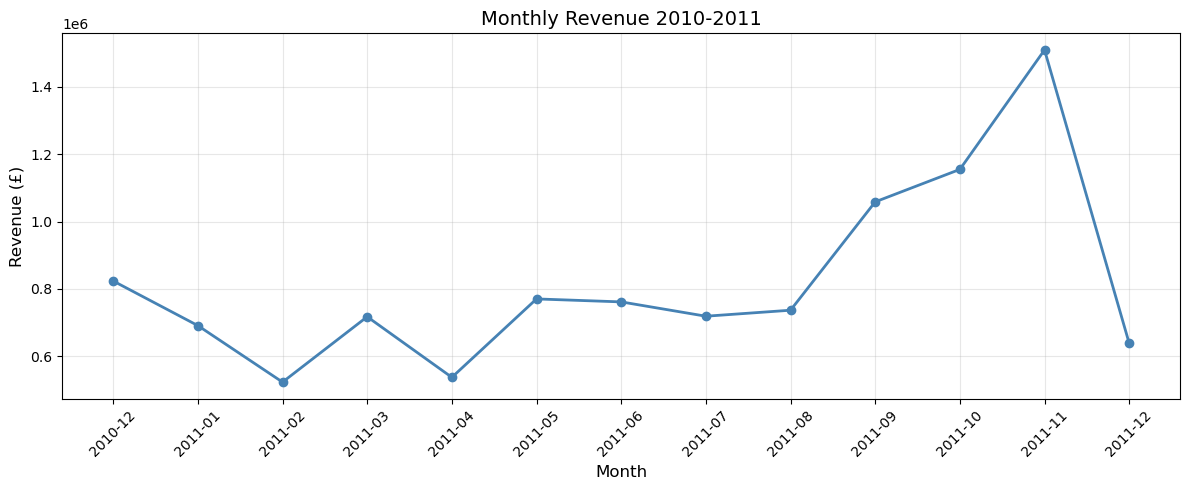

In [141]:
# ============================================
# CHART 1 — Monthly Revenue Line Chart
# Business Question: How did monthly revenue
#                    trend across 2010-2011?
# ============================================

# WHY LINE CHART?
# Line charts show TRENDS over time perfectly!
# Easy to spot peaks, drops, and patterns!
# Best chart type for time series data!

# KEY MATPLOTLIB LINES EXPLAINED:
# plt.figure(figsize=(12,5)) → set chart size
# plt.plot()                 → draw the line
# plt.title()                → chart heading
# plt.xlabel/ylabel()        → axis labels
# plt.xticks(rotation=45)    → rotate x labels
# plt.grid(alpha=0.3)        → light grid lines
# plt.tight_layout()         → auto fix spacing
# plt.show()                 → display chart

plt.figure(figsize=(12, 5))
plt.plot(df_monthly['month'], 
         df_monthly['revenue'], 
         marker='o',
         color='steelblue',
         linewidth=2)
plt.title('Monthly Revenue 2010-2011', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [144]:
df_countries = pd.read_sql_query("""
    SELECT Country,
           ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue
    FROM orders
    WHERE Quantity > 0
    GROUP BY Country
    ORDER BY total_revenue DESC
    LIMIT 10
""", conn)
df_countries

,Country,total_revenue
0,United Kingdom,9003097.96
1,Netherlands,285446.34
2,EIRE,283453.96
3,Germany,228867.14
4,France,209715.11
5,Australia,138521.31
6,Spain,61577.11
7,Switzerland,57089.90
8,Belgium,41196.34
9,Sweden,38378.33


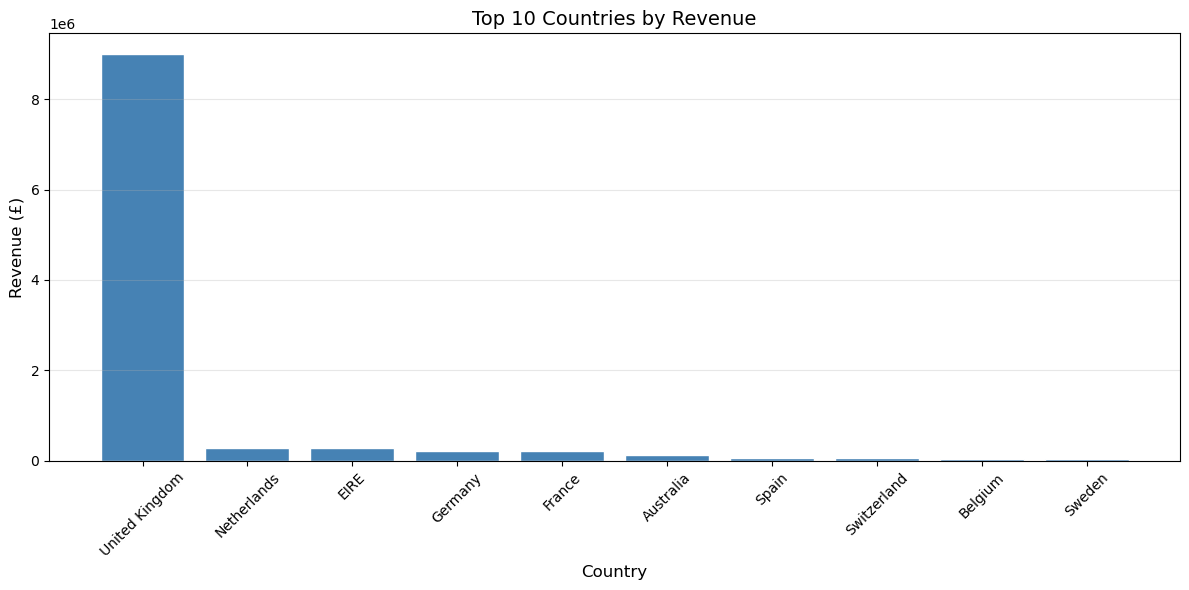

In [146]:
# ============================================
# CHART 2 — Top 10 Countries Bar Chart
# Business Question: Which countries generate
#                    most revenue?
# ============================================

# WHY BAR CHART?
# Bar charts compare values across categories!
# Easy to see which country dominates!
# Best chart for comparing multiple items!

# NOTE ABOUT UK:
# UK = £9M — dominates everything!
# Other 9 countries = £200K-£285K range
# This shows HIGH revenue concentration risk!
# Business should grow other markets!

plt.figure(figsize=(12, 6))
plt.bar(df_countries['Country'],
        df_countries['total_revenue'],
        color='steelblue',
        edgecolor='white')
plt.title('Top 10 Countries by Revenue', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [147]:
df_pie = pd.read_sql_query("""
    SELECT Country,
           ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue
    FROM orders
    WHERE Quantity > 0
    GROUP BY Country
    ORDER BY total_revenue DESC
    LIMIT 5
""", conn)
df_pie

,Country,total_revenue
0,United Kingdom,9003097.96
1,Netherlands,285446.34
2,EIRE,283453.96
3,Germany,228867.14
4,France,209715.11


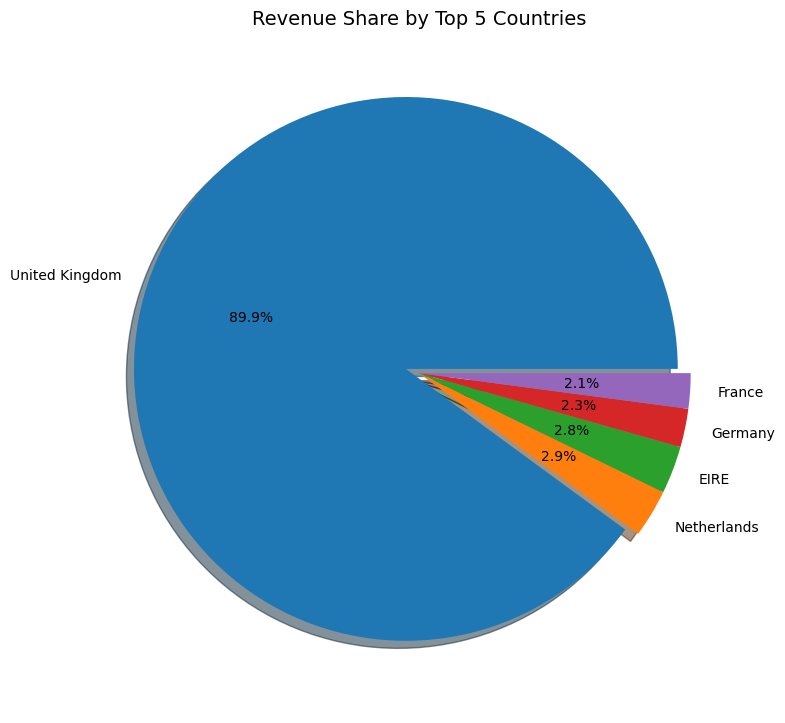

In [149]:
# ============================================
# CHART 3 — Revenue Share Pie Chart
# Business Question: What percentage of revenue
#                    comes from each top country?
# ============================================

# WHY PIE CHART?
# Pie charts show PERCENTAGE contribution!
# Perfect for showing how much each part
# contributes to the whole!
# Best when you want to show share/proportion!

# PIE vs BAR:
# Bar chart  → compare actual values
# Pie chart  → compare percentages of whole

# AUTOPCT EXPLAINED:
# autopct='%1.1f%%'
# %1.1f → show number with 1 decimal place
# %%    → show % symbol after number
# auto  → calculate percentage automatically!

# EXPLODE:
# Pulls one slice slightly out from center
# Used to highlight the most important slice!
# (0.05, 0, 0, 0, 0) → only UK slice pulled out!

explode = (0.05, 0, 0, 0, 0)

plt.figure(figsize=(8, 8))
plt.pie(df_pie['total_revenue'],
        labels=df_pie['Country'],
        autopct='%1.1f%%',
        explode=explode,
        shadow=True)
plt.title('Revenue Share by Top 5 Countries', fontsize=14)
plt.tight_layout()
plt.show()

In [150]:
df_orders = pd.read_sql_query("""
    SELECT Country,
           COUNT(*) AS total_orders
    FROM orders
    WHERE Quantity > 0
    GROUP BY Country
    ORDER BY total_orders DESC
    LIMIT 10
""", conn)
df_orders

,Country,total_orders
0,United Kingdom,486286
1,Germany,9042
2,France,8408
3,EIRE,7894
4,Spain,2485
5,Netherlands,2363
6,Belgium,2031
7,Switzerland,1967
8,Portugal,1501
9,Australia,1185


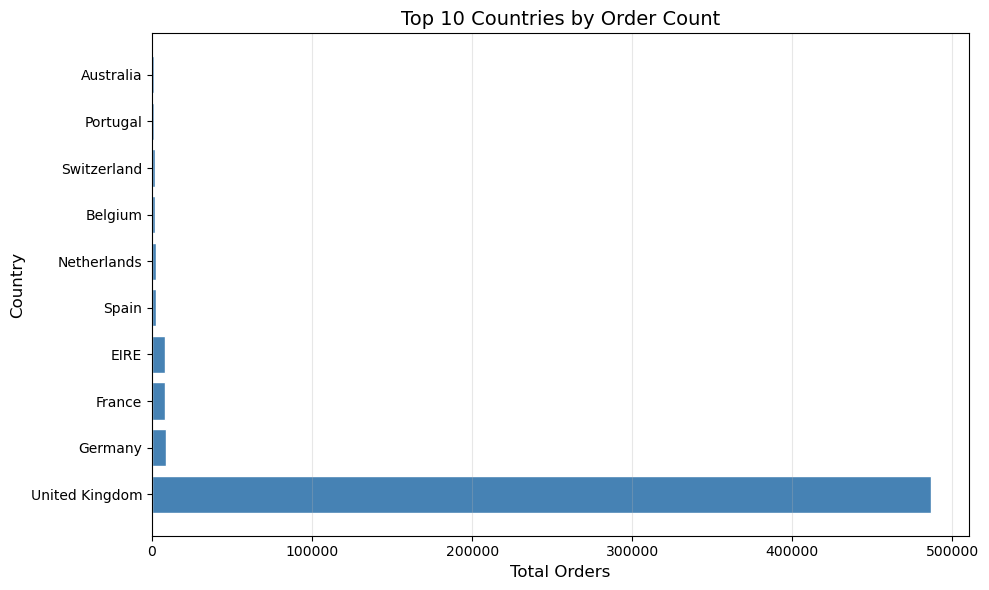

In [152]:
# ============================================
# CHART 4 — Horizontal Bar Chart
# Business Question: How does order count
#                    compare across countries?
# ============================================

# WHY HORIZONTAL BAR CHART?
# Country names are long → hard to rotate!
# Horizontal bars → country names easy to read!
# Better than vertical when many categories!

# plt.bar()  → vertical bars
# plt.barh() → horizontal bars (h = horizontal!)

plt.figure(figsize=(10, 6))
plt.barh(df_orders['Country'],
         df_orders['total_orders'],
         color='steelblue',
         edgecolor='white')
plt.title('Top 10 Countries by Order Count', fontsize=14)
plt.xlabel('Total Orders', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()